In [2]:
import pandas as pd

df = pd.read_csv("../data/processed/migration_dataset.csv")
print(df.shape)

(640, 26)


In [3]:
# Target
y = df["migration_pressure_score"]

# Features (ONLY _imp columns)
X = df[[col for col in df.columns if col.endswith("_imp")]]

In [4]:
print("Feature Names:")
print(X.columns.tolist())

print("\nNumber of Features:")
print(len(X.columns))

print("\nData Types:")
print(X.dtypes)

print("\nDataset Shape:")
print(X.shape)

Feature Names:
['rainfall_cv_imp', 'drought_freq_imp', 'flood_freq_imp', 'yield_cv_imp', 'production_std_imp', 'mpi_imp', 'headcount_ratio_imp', 'marginal_worker_rate_imp', 'worker_ratio_imp']

Number of Features:
9

Data Types:
rainfall_cv_imp             float64
drought_freq_imp            float64
flood_freq_imp              float64
yield_cv_imp                float64
production_std_imp          float64
mpi_imp                     float64
headcount_ratio_imp         float64
marginal_worker_rate_imp    float64
worker_ratio_imp            float64
dtype: object

Dataset Shape:
(640, 9)


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(model, name):
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print("MAE :", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R²  :", r2_score(y_test, y_pred))

evaluate(lr, "Linear Regression")
evaluate(rf, "Random Forest")


Linear Regression
MAE : 2.468376669513984e-07
RMSE: 2.901832794667659e-07
R²  : 0.9999999999814294

Random Forest
MAE : 0.016372904062500013
RMSE: 0.021004796522571794
R²  : 0.9026987669032787


In [6]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False).head(10))

mpi_imp                     0.451989
headcount_ratio_imp         0.267004
flood_freq_imp              0.103827
rainfall_cv_imp             0.065557
drought_freq_imp            0.032891
worker_ratio_imp            0.020524
marginal_worker_rate_imp    0.020201
production_std_imp          0.019856
yield_cv_imp                0.018151
dtype: float64


In [7]:
import joblib
joblib.dump(rf, "../models/random_forest_model.pkl")

['../models/random_forest_model.pkl']

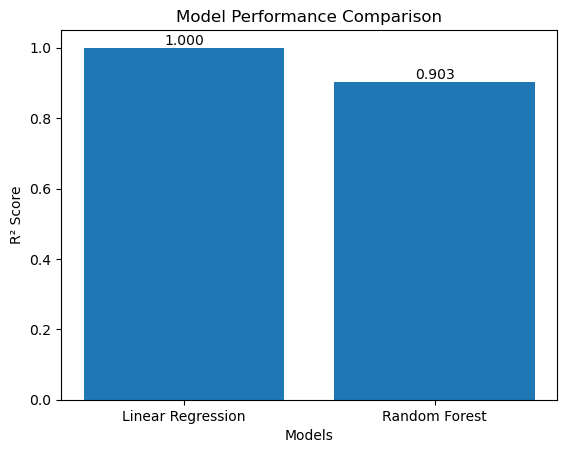

In [8]:
import matplotlib.pyplot as plt

models = ['Linear Regression', 'Random Forest']
r2_scores = [0.9999999999814294, 0.9026987669032787]

plt.figure()
bars = plt.bar(models, r2_scores)

# Add value labels on top
for bar, score in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
             f"{score:.3f}", ha='center', va='bottom')

plt.xlabel('Models')
plt.ylabel('R² Score')
plt.title('Model Performance Comparison')

plt.savefig('model_results.png', bbox_inches='tight')
plt.show()

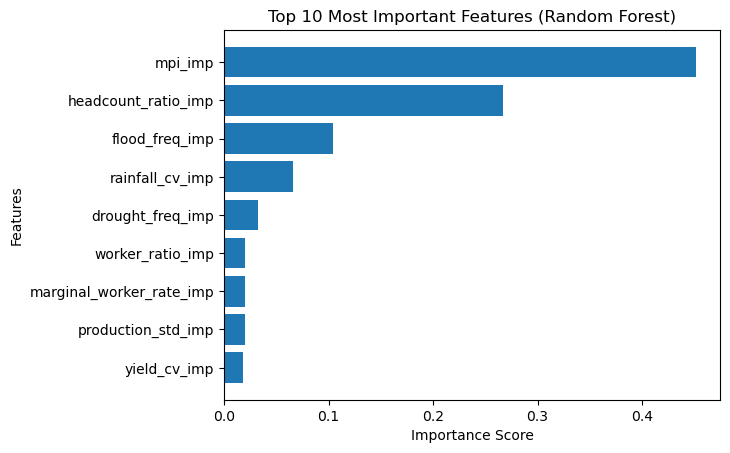

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract feature importance
importances = rf.feature_importances_
feature_names = X.columns

# Create dataframe
feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort descending
feat_df = feat_df.sort_values(by='Importance', ascending=False)

# Select top 10
top_features = feat_df.head(10)

# Plot
plt.figure()
plt.barh(top_features['Feature'], top_features['Importance'])

# Highest importance on top
plt.gca().invert_yaxis()

# Labels
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Top 10 Most Important Features (Random Forest)')

# Save image
plt.savefig('feature_importance.png', bbox_inches='tight')

plt.show()